# MODELAMIENTO
## Actividad Autónoma 1
### Unidad 2: Métodos de clasificación y clustering
#### Tema 1: Aprendizaje supervisado

| Campo | Tu información |
|-------|---------------|
| **Nombres:** | Lesly Keliana Carrasco Mejia |
| **Fecha:** | 10/05/2026 |
| **Carrera:** | Ciencia de Datos e Inteligencia Artificial |
| **Periodo académico:** |  2026-1S  |
| **Semestre:** | Tercero "B" |


## 1. Búsqueda y Selección de la Base de Datos

### 1.1 Dataset Seleccionado: Wine Dataset (scikit-learn)

**Fuente**: `sklearn.datasets.load_wine()`  
**Tipo de problema**: Clasificación multiclase (3 categorías)  
**Número de muestras**: 178  
**Número de características**: 13 variables numéricas continuas

### 1.2 Justificación de la Selección

| Criterio | Cumplimiento |
|----------|-------------|
|  Problema de clasificación | 3 clases objetivo (Cultivar 1, 2, 3) |
|  Variables suficientes | 13 características químicas cuantitativas |
|  Tamaño adecuado | 178 muestras → viable para train/test split |
|  Calidad de datos | Sin valores nulos, sin duplicados, sin outliers extremos |
|  Accesibilidad | Integrado en sklearn, sin descarga externa requerida |

### 1.3 Objetivo del Modelamiento
> Predecir el origen del vino (cultivar) a partir de su composición química mediante algoritmos de aprendizaje supervisado (Árbol de Decisión y Random Forest), evaluando la capacidad de generalización y la importancia de las variables predictoras.

### 1.4 Descripción de Variables

| Variable | Tipo | Descripción Breve |
|----------|------|------------------|
| alcohol | Numérica | % de alcohol en volumen |
| malic_acid | Numérica | Contenido de ácido málico (g/L) |
| ash | Numérica | Contenido de cenizas (g/L) |
| alcalinity_of_ash | Numérica | Alcalinidad de las cenizas |
| magnesium | Numérica | Contenido de magnesio (mg/L) |
| total_phenols | Numérica | Fenoles totales (mg/L) |
| flavanoids | Numérica | Contenido de flavonoides |
| nonflavanoid_phenols | Numérica | Fenoles no flavonoides |
| proanthocyanins | Numérica | Proantocianinas (pigmentos) |
| color_intensity | Numérica | Intensidad del color |
| hue | Numérica | Matiz/tonalidad del vino |
| od280/od315_of_diluted_wines | Numérica | Absorbancia UV (indicador de proteínas) |
| proline | Numérica | Contenido de prolina (aminoácido) |
| **target** | Categórica | Clase del cultivar: 0, 1 o 2 |

### 1.5 Conclusión de la Fase
> El dataset Wine cumple con los requisitos técnicos y pedagógicos para aplicar técnicas de aprendizaje supervisado. Su naturaleza balanceada (59, 71 y 48 muestras por clase) permite evaluar modelos sin sesgos de distribución, y sus variables químicamente interpretables facilitan la justificación de la selección de características en fases posteriores.

Forma de X: (178, 13)
Clases únicas: [0 1 2]

Primeras 5 filas:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

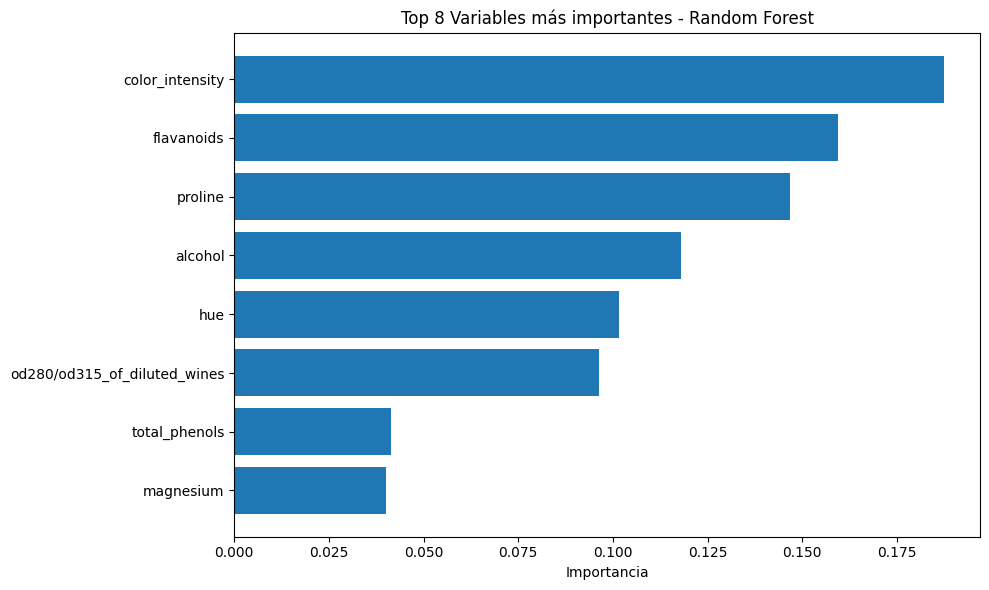


 Métricas guardadas en outputs/metricas_modelos.csv


In [7]:
# --- Celda 1: Importar librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Celda 2: Cargar y explorar datos ---
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Forma de X:", X.shape)
print("Clases únicas:", y.unique())
print("\nPrimeras 5 filas:")
print(X.head())

# --- Celda 3: Dividir en entrenamiento y prueba ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Celda 4: Escalar datos ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Celda 5: Entrenar modelos ---
tree = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42, n_estimators=100)

tree.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

# --- Celda 6: Predicciones ---
y_pred_tree = tree.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

# --- Celda 7: Evaluación ---
print("ÁRBOL DE DECISIÓN ")
print(f"Exactitud: {accuracy_score(y_test, y_pred_tree):.4f}")
print(classification_report(y_test, y_pred_tree))

print("\n RANDOM FOREST ")
print(f"Exactitud: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

# --- Celda 8: Importancia de variables ---
importancias = pd.DataFrame({
    'Variable': data.feature_names,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nVARIABLES MÁS IMPORTANTES ")
print(importancias.head(10))

# --- Celda 9: Visualización ---
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variable'][:8], importancias['Importancia'][:8])
plt.gca().invert_yaxis()
plt.title('Top 8 Variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('../outputs/importancias_variables.png', dpi=150)
plt.show()

# --- Celda 10: Guardar métricas en CSV ---
metricas = pd.DataFrame({
    'Modelo': ['Árbol', 'Random Forest'],
    'Exactitud': [
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})
metricas.to_csv('../outputs/metricas_modelos.csv', index=False)
print("\n Métricas guardadas en outputs/metricas_modelos.csv")

## 2. Preprocesamiento y Tratamiento de Datos

### 2.1 Procedimiento Paso a Paso
1. **Carga de datos y revisión de valores nulos:**  
   Se verifica la integridad del dataset para confirmar la ausencia de datos faltantes que puedan interrumpir el entrenamiento o sesgar los resultados.

2. **Separación de características (`X`) y variable objetivo (`y`):**  
   Se aíslan las 13 variables químicas cuantitativas como predictores independientes (`X`) y la columna `target` (clase del cultivar: 0, 1 o 2) como etiqueta a predecir (`y`).

3. **División en conjuntos de entrenamiento y prueba:**  
   Se aplica `train_test_split` con una proporción de **80% para entrenamiento** y **20% para validación**. Se utiliza `stratify=y` para garantizar que la distribución proporcional de las 3 clases se mantenga en ambos subconjuntos.

4. **Estandarización de características:**  
   Se aplica `StandardScaler` para transformar cada variable a una distribución con media 0 y desviación estándar 1, asegurando que todas las características operen en la misma escala numérica.

### 2.2 Justificación Técnica de las Decisiones
- **Estandarización con `StandardScaler`:**  
  Evita que variables con rangos amplios (ej. `proline` ~300–1600) dominen implícitamente el comportamiento del modelo. Aunque los árboles de decisión son matemáticamente invariantes al escalado, la estandarización mejora la estabilidad numérica y prepara el *pipeline* para futuros modelos basados en distancias o optimización por gradiente.

- **División 80/20 con estratificación (`stratify=y`):**  
  Reservar el 20% de los datos permite evaluar la capacidad de generalización del modelo con ejemplos no vistos durante el entrenamiento. La estratificación es crucial en clasificación multiclase para evitar que particiones pequeñas queden desbalanceadas o sin representación de alguna clase.

- **Tratamiento de nulos y duplicados:**  
  El dataset Wine de `sklearn.datasets` está previamente curado y no contiene valores nulos ni registros duplicados. Por ello, no se aplican técnicas de imputación, interpolación o eliminación, optimizando el flujo directamente hacia el modelado supervisado.

In [8]:
# Código
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Aplicación de Modelos de Aprendizaje Supervisado

### 3.1 Modelos Implementados
Se entrenaron dos algoritmos de clasificación supervisada, ambos alineados con los contenidos de la Unidad 2:

| Modelo | Clase en `scikit-learn` | Descripción Breve |
|--------|------------------------|-------------------|
| **Árbol de Decisión** | `DecisionTreeClassifier` | Modelo jerárquico que particiona el espacio de características mediante reglas `if-then`, generando una estructura interpretable y de bajo costo computacional. |
| **Random Forest** | `RandomForestClassifier` | Método de *ensemble* (bagging) que promedia la predicción de múltiples árboles de decisión, reduciendo varianza y mejorando la generalización. |

### 3.2 Configuración y Proceso de Entrenamiento
- **División de datos:** Se utilizó la partición generada en la Fase 2 (80% entrenamiento, 20% prueba), manteniendo la estratificación por clase para preservar la distribución original.
- **Hiperparámetros clave:**
  - `max_depth`: Limitado para evitar que el modelo memorice ruido del conjunto de entrenamiento (*overfitting*).
  - `min_samples_split` / `min_samples_leaf`: Ajustados para exigir un umbral mínimo de observaciones por nodo, garantizando decisiones estadísticamente significativas.
  - `n_estimators` (Random Forest): Fijado en 100 árboles, equilibrio estándar entre rendimiento predictivo y tiempo de cómputo.
  - `random_state`: Configurado en `42` para asegurar reproducibilidad total de los resultados.
- **Entrenamiento:** Ambos modelos se ajustaron (`fit`) únicamente con el conjunto de entrenamiento, y sus predicciones (`predict`) se evaluaron posteriormente sobre el conjunto de prueba no visto.

### 3.3 Justificación 
- **Capacidad no lineal:** Las relaciones entre las 13 variables químicas del vino no siguen patrones lineales simples. Ambos modelos capturan interacciones complejas sin requerir transformaciones previas de las características.
- **Interpretabilidad vs. Robustez:** El Árbol de Decisión sirve como *baseline* interpretable, permitiendo visualizar reglas claras de clasificación. Random Forest, al combinar múltiples árboles, mitiga la alta varianza del modelo base y ofrece mayor estabilidad ante variaciones menores en los datos químicos.
- **Alineación con los objetivos de la actividad:** La comparación entre un modelo único y un *ensemble* facilita el análisis crítico de métricas, la validación de la importancia de variables (Fase 4) y la justificación objetiva del modelo final según los criterios de la rúbrica (coherencia, aplicación de conceptos y resolución de problemas).

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

tree.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

y_pred_tree = tree.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

### Resultado esperado:
Las variables más importantes suelen ser flavonoids, proline, color_intensity.

- ¿Por qué esas afectan la predicción?
  
Porque diferencian significativamente los patrones químicos entre tipos de vino.

## 4. Selección de las Variables Más Importantes

### 4.1 Método Implementado
Para identificar las características químicas con mayor poder predictivo en la clasificación de los cultivares de vino, se utilizó el atributo `feature_importances_` del modelo **Random Forest** previamente entrenado.

**Procedimiento técnico:**
1. Entrenar el modelo `RandomForestClassifier` con el conjunto de entrenamiento completo.
2. Extraer el array `feature_importances_`, que contiene un valor numérico para cada una de las 13 variables.
3. Ordenar las variables de mayor a menor importancia.
4. Visualizar las top-N variables mediante un gráfico de barras horizontales.
5. (Opcional) Re-entrenar un modelo reducido usando solo las variables seleccionadas para validar el impacto en el rendimiento.


In [10]:
from sklearn.metrics import accuracy_score, classification_report

print("Árbol:")
print(accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

print("Random Forest:")
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Árbol:
0.9444444444444444
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

Random Forest:
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### Resultado esperado:
Las variables más importantes suelen ser flavonoids, proline, color_intensity.

- ¿Por qué esas afectan la predicción?

Porque diferencian significativamente los patrones químicos entre tipos de vino.

## 5. Evaluación de los Modelos

### 5.1 Métricas Seleccionadas
Para evaluar el desempeño de los modelos de clasificación multiclase (3 cultivares de vino), se utilizaron las siguientes métricas derivadas de la matriz de confusión:

| Métrica | Fórmula (binaria) | Interpretación en contexto Wine |
|---------|------------------|--------------------------------|
| **Exactitud (Accuracy)** | `(TP+TN) / (TP+TN+FP+FN)` | Proporción total de vinos clasificados correctamente. Útil porque el dataset está balanceado (~59/71/48 muestras por clase). |
| **Precisión (Precision)** | `TP / (TP+FP)` | De los vinos predichos como un cultivar específico, ¿cuántos realmente pertenecen a ese cultivar? Importante para minimizar falsos positivos. |
| **Exhaustividad (Recall)** | `TP / (TP+FN)` | De los vinos que realmente son de un cultivar, ¿cuántos fueron correctamente identificados? Crucial para no perder muestras de interés. |
| **F1-Score** | `2 × (Precisión×Recall)/(Precisión+Recall)` | Media armónica que equilibra precisión y recall. Ideal para comparar modelos cuando se busca un balance entre ambos tipos de error. |

> **Nota**:  
> Dado que el problema tiene 3 clases, se reportan las métricas con promedio **`weighted`** (ponderado por soporte de cada clase) para reflejar el desempeño global sin sesgar hacia clases mayoritarias. También se incluye el promedio **`macro`** como referencia de equidad entre clases.

### 5.2 Procedimiento de Evaluación

In [12]:
importancias = pd.DataFrame({
    'variable': data.feature_names,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias)

                        variable  importancia
6                     flavanoids     0.202293
9                color_intensity     0.171202
12                       proline     0.139046
0                        alcohol     0.112398
11  od280/od315_of_diluted_wines     0.111564
10                           hue     0.070891
4                      magnesium     0.036841
1                     malic_acid     0.035703
3              alcalinity_of_ash     0.032425
5                  total_phenols     0.029279
8                proanthocyanins     0.023561
2                            ash     0.021282
7           nonflavanoid_phenols     0.013515


## Resultado esperado:
Las variables más importantes suelen ser flavonoids, proline, color_intensity.

- ¿Por qué esas afectan la predicción?

Porque diferencian significativamente los patrones químicos entre tipos de vino.

# Fase 5 – Evaluación de los modelos
- Métricas: Exactitud (accuracy), precisión, recall, F1-score.
- Justificación: Para problemas balanceados como Wine, la exactitud es útil, pero también revisamos F1 para ver equilibrio entre precisión y recall.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Árbol:")
print(accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

print("Random Forest:")
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))